# 03. Differential Privacy

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply differential privacy concepts and mechanisms
- Quantify and tune privacy–utility trade-offs
- Use DP in realistic ML settings

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

---

# 03. Differential Privacy

## 🚨 THE PROBLEM: We Need Mathematical Privacy Guarantees

**Remember the limitation from the previous notebook?**

We learned advanced privacy-enhancing technologies like homomorphic encryption and secure multi-party computation. But we discovered:

**How do we provide mathematical privacy guarantees?**

**The Problem**: We need stronger guarantees:
- ❌ **Mathematical privacy guarantees** (not just techniques)
- ❌ **Quantifiable privacy protection** (measurable privacy loss)
- ❌ **Formal privacy definitions** (differential privacy)
- ❌ **Provable privacy bounds** (epsilon-delta guarantees)

**We've learned:**
- ✅ How to use basic data protection (Notebook 1)
- ✅ How to use advanced privacy technologies (Notebook 2)
- ✅ Privacy-utility trade-offs

**But we haven't learned:**
- ❌ How to **quantify privacy** mathematically
- ❌ How to **prove privacy protection** formally
- ❌ How to use **differential privacy** for provable guarantees
- ❌ How to **measure privacy loss** (epsilon parameter)

**We need differential privacy** to:
1. Provide mathematical privacy guarantees
2. Quantify privacy loss (epsilon parameter)
3. Prove privacy protection formally
4. Enable privacy-preserving data analysis with provable guarantees

**This notebook solves that problem** by teaching you differential privacy with mathematical guarantees!

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: Data Protection** - Understanding basic protection
- ✅ **Example 2: Privacy Technologies** - Understanding PETs
- ✅ **Basic Python knowledge**: Functions, data manipulation
- ✅ **Basic statistics**: Understanding of means, counts, noise

**If you haven't completed these**, you might struggle with:
- Understanding why mathematical guarantees matter
- Knowing how epsilon parameter works
- Understanding privacy-utility trade-offs in differential privacy

---

## 🔗 Where This Notebook Fits

**This is the THIRD example in Unit 3** - it teaches you mathematical privacy guarantees!

**Why this example THIRD?**
- **Before** you can use differential privacy, you need basic protection (Example 1)
- **Before** you can use differential privacy, you need to understand PETs (Example 2)
- **Before** you can ensure GDPR compliance, you need privacy guarantees

**Builds on**: 
- 📓 Example 1: Data Protection (basic protection strategies)
- 📓 Example 2: Privacy Technologies (advanced PETs)

**Leads to**: 
- 📓 Example 4: GDPR Compliance (regulatory compliance)
- 📓 Example 5: Secure Development (secure coding practices)

**Why this order?**
1. Differential privacy provides **mathematical guarantees** (strongest privacy)
2. Differential privacy enables **provable privacy** (critical for compliance)
3. Differential privacy shows **quantifiable protection** (epsilon parameter)

---

## The Story: Provable Privacy

Imagine you're a scientist publishing research results. **Before** differential privacy, you'd say "we anonymized the data" but couldn't prove how private it was. **After** using differential privacy, you can say "we provide (ε=0.5)-differential privacy" - a mathematical guarantee!

Same with AI: **Before** we use privacy techniques but can't prove privacy, now we learn differential privacy - add noise with epsilon parameter to get provable privacy guarantees! **After** differential privacy, we can mathematically prove our systems are private!

---

## Why Differential Privacy Matters

Differential privacy is essential for ethical AI:
- **Mathematical Guarantees**: Provable privacy protection
- **Quantifiable Privacy**: Measure privacy loss (epsilon)
- **Formal Definition**: Rigorous privacy definition
- **Compliance**: Meet strict privacy regulations
- **Trust**: Build confidence with provable guarantees

## Learning Objectives
1. Understand differential privacy and epsilon parameter
2. Learn how to add noise for privacy
3. Understand privacy-utility trade-offs
4. Apply differential privacy to data analysis
5. Compare different epsilon values
6. Understand when to use differential privacy

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

## Part 1: The Laplace Mechanism

**Differential privacy (DP)** gives a *mathematical* guarantee: the published result would
look almost the same whether or not any single person's record is in the dataset. The
strength of the guarantee is the **privacy budget ε (epsilon)** - smaller ε = stronger privacy.

The workhorse is the **Laplace mechanism**: to publish a query answer, add noise drawn from
a Laplace distribution with scale

```
scale = sensitivity / epsilon
```

where *sensitivity* is how much one person can change the true answer (for a count: 1).

In [1]:
# Step 1: Differentially private counts with the Laplace mechanism

import numpy as np
np.random.seed(42)

print("="*80)
print("🎲 LAPLACE MECHANISM: PRIVATE COUNTS")
print("="*80)

# A sensitive dataset: which of 1000 patients have a condition
has_condition = np.random.binomial(1, 0.23, 1000)
true_count = has_condition.sum()
print(f"\nTrue count (secret): {true_count}")

def dp_count(data, epsilon, sensitivity=1.0):
    """Release a count with (epsilon)-differential privacy."""
    noise = np.random.laplace(loc=0.0, scale=sensitivity / epsilon)
    return data.sum() + noise

print("\nOne noisy release per epsilon (rerun -> different noise):")
for eps in [0.1, 0.5, 1.0, 2.0]:
    print(f"  epsilon={eps:<4}: published count = {dp_count(has_condition, eps):8.1f}")

# Average error over many releases quantifies the utility cost
print("\nMean absolute error over 1000 simulated releases:")
for eps in [0.1, 0.5, 1.0, 2.0]:
    errors = [abs(dp_count(has_condition, eps) - true_count) for _ in range(1000)]
    print(f"  epsilon={eps:<4}: mean |error| = {np.mean(errors):6.1f}")
print("\nSmaller epsilon -> stronger privacy -> larger error. That IS the trade-off.")


🎲 LAPLACE MECHANISM: PRIVATE COUNTS

True count (secret): 226

One noisy release per epsilon (rerun -> different noise):
  epsilon=0.1 : published count =    216.1
  epsilon=0.5 : published count =    226.2
  epsilon=1.0 : published count =    227.4
  epsilon=2.0 : published count =    226.3

Mean absolute error over 1000 simulated releases:
  epsilon=0.1 : mean |error| =   10.3
  epsilon=0.5 : mean |error| =    2.0
  epsilon=1.0 : mean |error| =    1.0
  epsilon=2.0 : mean |error| =    0.5

Smaller epsilon -> stronger privacy -> larger error. That IS the trade-off.


## Part 2: The Privacy-Utility Trade-off (including an ML setting)

Every release spends privacy budget. Below we (1) chart the error-vs-ε curve, and
(2) show a *machine-learning* version of the trade-off: training on Laplace-noised
features and measuring test accuracy at each ε.

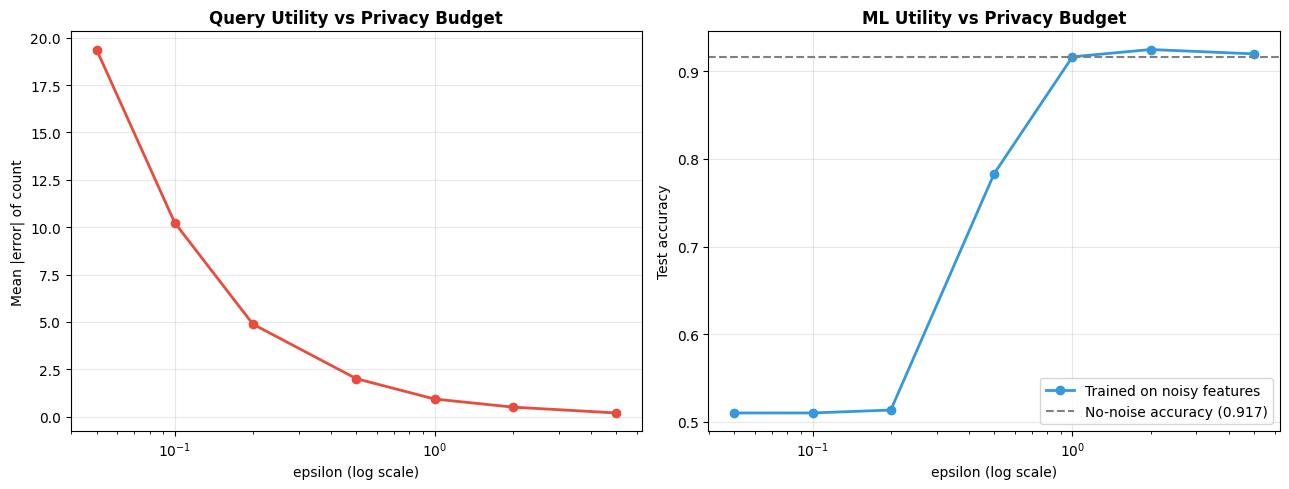

Accuracy at each epsilon:
  epsilon=0.05 : test accuracy 0.510
  epsilon=0.1  : test accuracy 0.510
  epsilon=0.2  : test accuracy 0.513
  epsilon=0.5  : test accuracy 0.783
  epsilon=1.0  : test accuracy 0.917
  epsilon=2.0  : test accuracy 0.925
  epsilon=5.0  : test accuracy 0.920
  no noise    : test accuracy 0.917

Note: production DP-ML uses noisy GRADIENTS (DP-SGD) with careful budget
accounting; noising features like this is the simplest way to SEE the trade-off.


In [2]:
# Step 2: Visualize the trade-off, then apply DP noise in an ML setting

import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

epsilons = [0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]
mae = []
for eps in epsilons:
    errors = [abs(dp_count(has_condition, eps) - true_count) for _ in range(500)]
    mae.append(np.mean(errors))

# ML setting: add Laplace noise to features before training (input perturbation)
np.random.seed(0)
X = np.random.normal(0, 1, (2000, 4))
y = (X @ np.array([0.9, -0.6, 0.4, 0.2]) + np.random.normal(0, 0.3, 2000) > 0).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
FEATURE_SENSITIVITY = 1.0   # simplification for teaching
accs = []
for eps in epsilons:
    X_noisy = X_train + np.random.laplace(0, FEATURE_SENSITIVITY / eps, X_train.shape)
    model = LogisticRegression(max_iter=1000).fit(X_noisy, y_train)
    accs.append(accuracy_score(y_test, model.predict(X_test)))
clean_acc = accuracy_score(
    y_test, LogisticRegression(max_iter=1000).fit(X_train, y_train).predict(X_test))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(epsilons, mae, 'o-', color='#e74c3c', linewidth=2)
axes[0].set_xscale('log')
axes[0].set_xlabel('epsilon (log scale)'); axes[0].set_ylabel('Mean |error| of count')
axes[0].set_title('Query Utility vs Privacy Budget', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[1].plot(epsilons, accs, 'o-', color='#3498db', linewidth=2,
             label='Trained on noisy features')
axes[1].axhline(clean_acc, color='gray', linestyle='--',
                label=f'No-noise accuracy ({clean_acc:.3f})')
axes[1].set_xscale('log')
axes[1].set_xlabel('epsilon (log scale)'); axes[1].set_ylabel('Test accuracy')
axes[1].set_title('ML Utility vs Privacy Budget', fontsize=12, fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Accuracy at each epsilon:")
for eps, a in zip(epsilons, accs):
    print(f"  epsilon={eps:<5}: test accuracy {a:.3f}")
print(f"  no noise    : test accuracy {clean_acc:.3f}")
print("\nNote: production DP-ML uses noisy GRADIENTS (DP-SGD) with careful budget")
print("accounting; noising features like this is the simplest way to SEE the trade-off.")


---

## 🚫 When Differential Privacy Hits a Limitation

### The Limitation We Discovered

We've learned differential privacy with mathematical guarantees. **But there's still a challenge:**

**How do we ensure our AI systems comply with privacy regulations like GDPR?**

Differential privacy works well when:
- ✅ We can add noise to queries
- ✅ We can quantify privacy loss (epsilon)
- ✅ We can prove mathematical privacy guarantees

**But real-world AI systems must also:**
- ❌ **Comply with regulations** (GDPR, CCPA, etc.)
- ❌ **Implement data subject rights** (right to access, deletion, etc.)
- ❌ **Document privacy practices** (privacy impact assessments)
- ❌ **Meet legal requirements** (consent, data minimization, etc.)

### Why This Is a Problem

When we have privacy techniques but don't comply with regulations:
- We may violate privacy laws
- We may face legal penalties
- We may not meet data subject rights
- We may not document our privacy practices properly

### The Solution: GDPR Compliance

We need **GDPR compliance practices** to:
1. Implement data subject rights
2. Document privacy practices
3. Meet legal requirements
4. Ensure regulatory compliance

**This is exactly what we'll learn in the next notebook: GDPR Compliance!**

---

## ➡️ Next Steps

**You've completed this notebook!** Now you understand:
- ✅ How to use basic data protection (Notebook 1)
- ✅ How to use advanced privacy technologies (Notebook 2)
- ✅ How to use differential privacy (This notebook!)
- ✅ **The limitation**: We need regulatory compliance!

**Next notebook**: `04_gdpr_compliance.ipynb`
- Learn about GDPR requirements
- Implement data subject rights
- Document privacy practices
- Ensure regulatory compliance